<a href="https://colab.research.google.com/github/Arati9703/customer-segmentation-kmeans/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step-1 importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Step-2 reading data

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Visualization

Age Distribution

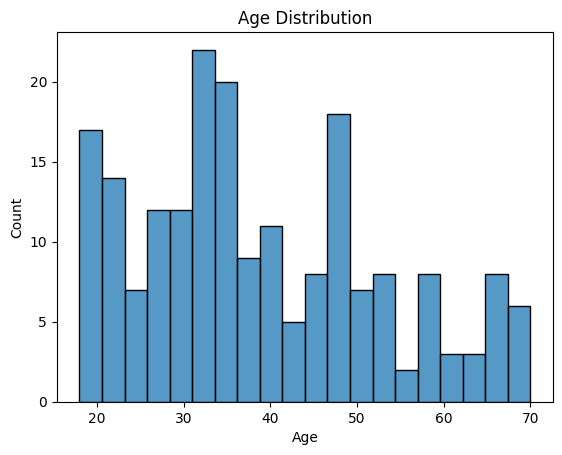

In [ ]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

Income vs Spending Score

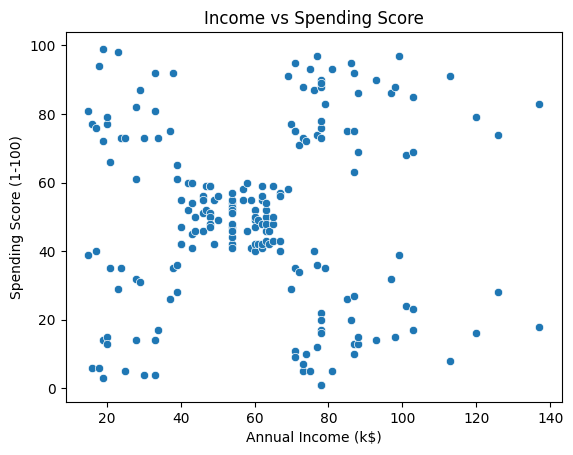

In [ ]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

Gender Count

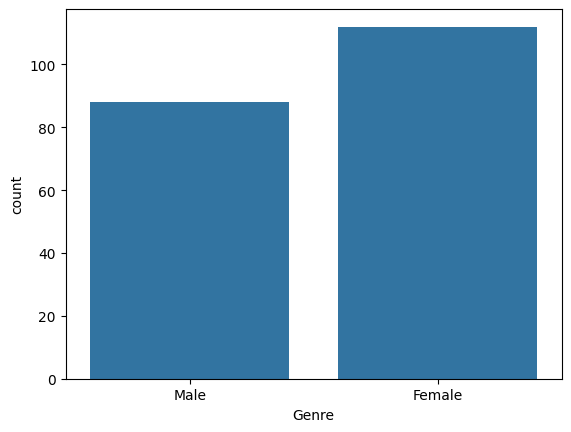

In [ ]:
sns.countplot(x='Genre', data=df)
plt.show()

Data Preprocessing

Encode categorical (IMPORTANT)

In [ ]:
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})

Feature Selection

In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre']]

⚠️ NOTE (Clustering Project)

👉 No y (unsupervised learning)
👉 No train-test split required

Find Optimal Clusters (Elbow Method)

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

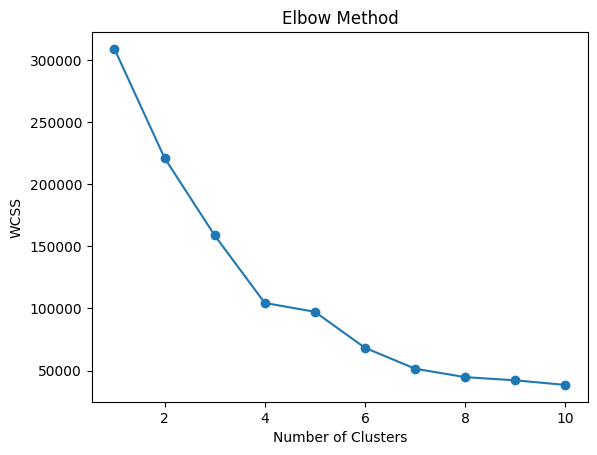

In [ ]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Model 1 (K=3)

In [ ]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)
kmeans_3.fit(X)

labels_3 = kmeans_3.labels_
score_3 = silhouette_score(X, labels_3)

score_3

np.float64(0.33545193002465656)

Model 2 (K=4)

In [ ]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
kmeans_4.fit(X)

labels_4 = kmeans_4.labels_
score_4 = silhouette_score(X, labels_4)

score_4

np.float64(0.4052954330641215)

Model 3 (K=5)

In [ ]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
kmeans_5.fit(X)

labels_5 = kmeans_5.labels_
score_5 = silhouette_score(X, labels_5)

score_5

np.float64(0.3574050351346702)

Compare Models

In [ ]:
results = pd.DataFrame({
    'Clusters': [3, 4, 5],
    'Silhouette Score': [score_3, score_4, score_5]
})

results

,Clusters,Silhouette Score
0,3,0.335452
1,4,0.405295
2,5,0.357405


final model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

Visualization of Clusters

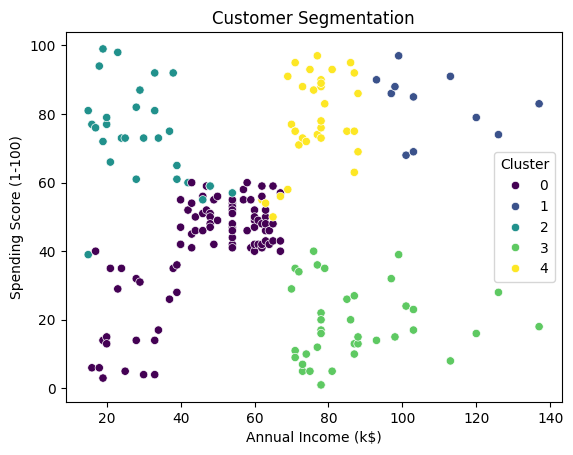

In [ ]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis'
)

plt.title("Customer Segmentation")
plt.show()

STEP-BY-STEP CROSS VERIFICATION

In [ ]:
print("Silhouette Scores:")
print("K=3:", score_3)
print("K=4:", score_4)
print("K=5:", score_5)

🔹 STEP 2: Final Decision Justification

👉 Example:

If K=4 > K=5 → say K=4 is better
If K=5 is close → still acceptable

VISUAL CROSS CHECK (VERY IMPORTANT)

In [ ]:
df['Cluster_4'] = kmeans_4.labels_

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_4',
    data=df,
    palette='viridis'
)

plt.title("Clusters (K=4)")
plt.show()

WHAT TO OBSERVE

Ask yourself:

Which looks cleaner?
Less overlap?
Better separation?

👉 That is your final K

🎯 FINAL SELECTION (IMPORTANT)

👉 Choose ONE:

✔ If K=4 better:

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

If K=5 better:


In [ ]:
#📊 FINAL MODEL (CONFIRMED)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [ ]:
#FINAL VISUAL (KEEP THIS ONLY IN PROJECT)
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis'
)

plt.title("Final Customer Segmentation")
plt.show()

In [ ]:
#Cluster Count
df['Cluster'].value_counts()

In [ ]:
# Cluster Means (VERY POWERFUL)
df.groupby('Cluster').mean()

# 👉 This gives:

# average income
# average spending